vw_dataset
- Plots
- Correlation Matrices
- Insights
- Feature-engineering Decisions

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, normaltest, anderson

In [46]:
vws_dataset = pd.read_parquet(
    "../data/processed/vws_dataset.parquet"
)

In [5]:
vws_dataset.shape

(70128, 14)

In [6]:
vws_dataset.head()

,timestamp,ws100,wd100,ws10,wd10,wind_shear,relative_humidity,air_density,blh,tcc,tp,ssrd,i10fg,WIND
0,2018-01-01 00:00:00,12.281535,250.820054,8.888463,196.219967,1.477310,85.497575,1.221705,963.648702,0.865433,0.000137,0.0,13.781487,8673.0
1,2018-01-01 01:00:00,12.115093,248.852093,8.729048,198.381376,1.485777,84.710206,1.222602,978.021734,0.768974,0.000084,0.0,13.967654,8613.0
2,2018-01-01 02:00:00,11.805504,245.666682,8.436531,201.805059,1.493257,84.066922,1.223426,946.694984,0.637181,0.000076,0.0,13.612556,8418.5
3,2018-01-01 03:00:00,11.557783,242.461919,8.252082,205.148087,1.499402,84.011453,1.224199,902.616008,0.660511,0.000086,0.0,12.992998,8299.0
4,2018-01-01 04:00:00,11.096890,239.026854,7.947670,208.674549,1.496604,84.741920,1.224817,845.336124,0.651387,0.000078,0.0,12.466838,8197.5


In [7]:
vws_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70128 entries, 0 to 70127
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          70128 non-null  datetime64[ns]
 1   ws100              70128 non-null  float64       
 2   wd100              70128 non-null  float64       
 3   ws10               70128 non-null  float64       
 4   wd10               70128 non-null  float64       
 5   wind_shear         70128 non-null  float64       
 6   relative_humidity  70128 non-null  float64       
 7   air_density        70128 non-null  float64       
 8   blh                70128 non-null  float64       
 9   tcc                70128 non-null  float64       
 10  tp                 70128 non-null  float64       
 11  ssrd               70128 non-null  float64       
 12  i10fg              70128 non-null  float64       
 13  WIND               70128 non-null  float64       
dtypes: dat

In [8]:
vws_dataset.isna().sum()

timestamp            0
ws100                0
wd100                0
ws10                 0
wd10                 0
wind_shear           0
relative_humidity    0
air_density          0
blh                  0
tcc                  0
tp                   0
ssrd                 0
i10fg                0
WIND                 0
dtype: int64

In [9]:
vws_dataset.describe()

,timestamp,ws100,wd100,ws10,wd10,wind_shear,relative_humidity,air_density,blh,tcc,tp,ssrd,i10fg,WIND
count,70128,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,7.012800e+04,70128.000000,70128.000000
mean,2021-12-31 23:30:00,8.039510,197.860126,5.851308,194.933638,1.442604,82.184881,1.232509,637.854913,0.696992,0.000120,4.332503e+05,9.272112,6405.289214
min,2018-01-01 00:00:00,1.323363,23.821625,1.224409,9.532726,1.077694,51.219878,1.174926,40.777512,0.004322,0.000000,0.000000e+00,2.392417,0.000000
25%,2020-01-01 11:45:00,5.735230,151.585214,4.233528,152.744885,1.367501,78.224149,1.214956,425.461141,0.556874,0.000015,0.000000e+00,6.687815,3055.500000
50%,2021-12-31 23:30:00,7.603423,205.615751,5.541019,199.537314,1.453060,83.155358,1.230099,604.582059,0.723451,0.000055,2.466794e+04,8.710956,5817.250000
75%,2024-01-01 11:15:00,9.967873,246.515051,7.217673,240.417975,1.518571,87.042502,1.248353,816.791404,0.870617,0.000153,6.967843e+05,11.356937,9356.500000
max,2025-12-31 23:00:00,22.573850,346.715631,15.527731,335.445620,8.180838,97.793161,1.304831,1970.305370,1.000000,0.002080,3.051823e+06,27.760490,18321.500000
std,NaN,3.018534,63.696203,2.117383,61.092723,0.122845,6.647127,0.023068,288.873232,0.209792,0.000170,6.449809e+05,3.416833,3989.958680


EDA of Target Variable

In [10]:
vws_dataset["WIND"].describe()

count    70128.000000
mean      6405.289214
std       3989.958680
min          0.000000
25%       3055.500000
50%       5817.250000
75%       9356.500000
max      18321.500000
Name: WIND, dtype: float64

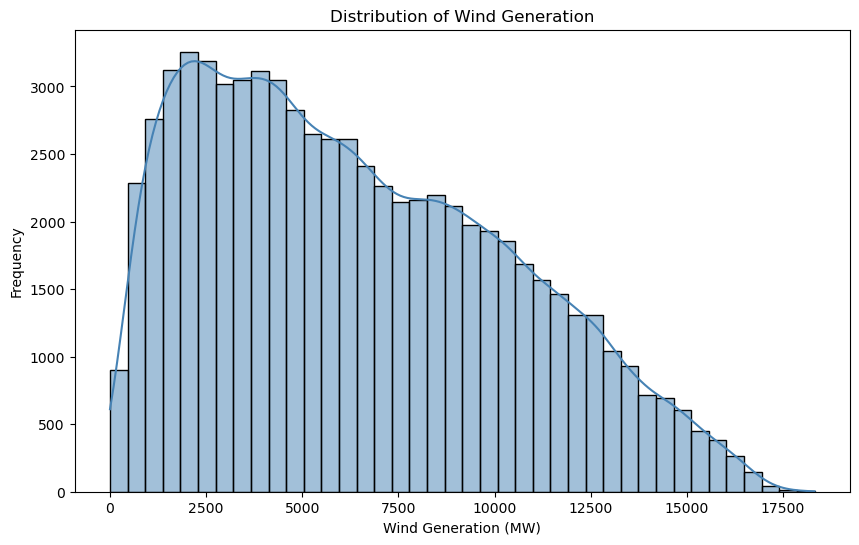

In [12]:
#histogram
plt.figure(figsize=(10,6))

sns.histplot(
    vws_dataset["WIND"],
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Wind Generation")
plt.xlabel("Wind Generation (MW)")
plt.ylabel("Frequency")

plt.show()

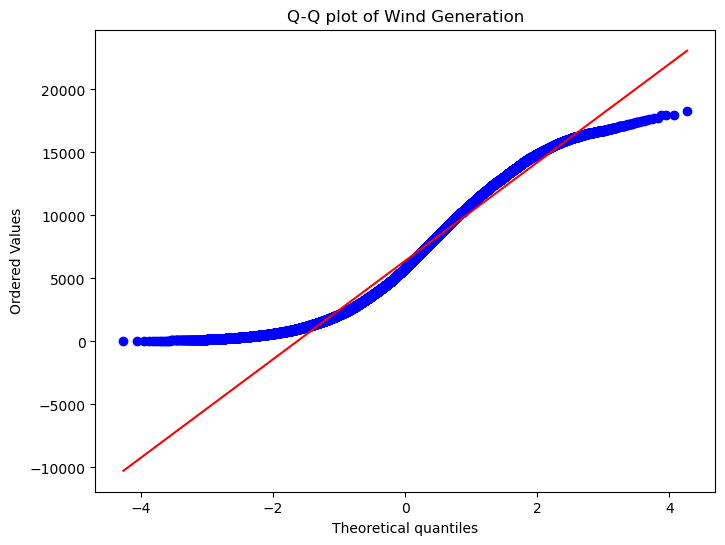

In [13]:
#qq_plot

plt.figure(figsize=(8,6))

stats.probplot(vws_dataset["WIND"], dist="norm", plot=plt)

plt.title("Q-Q plot of Wind Generation")

plt.show()

In [14]:
#skewness and kurtosis

skewness = stats.skew(vws_dataset["WIND"])
kurtosis = stats.kurtosis(vws_dataset["WIND"])

print(f"Skewness: {skewness: .3f}")
print(f"Kurtosis: {kurtosis: .3f}")

Skewness:  0.464
Kurtosis: -0.713


In [15]:
f_sample = vws_dataset["WIND"]

stat, p = shapiro(f_sample)

print("Shapiro Wilk Test")
print(f"Statistics: {stat: .3f}")
print(f"P-value: {p: .4e}")

if p > 0.05:
    print("Fail to reject NH, it is normally distributed")
else:
    print("Reject NH, it is not distributed normally")

Shapiro Wilk Test
Statistics:  0.958
P-value:  8.1838e-83
Reject NH, it is not distributed normally


c:\Users\LOQ\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 70128.
  res = hypotest_fun_out(*samples, **kwds)


In [16]:
#shapiro wilk test has best result for smaller dataset

t_sample = vws_dataset["WIND"].sample(5000, random_state=42)

stat, p = shapiro(t_sample)

print("Shapiro Wilk Test")
print(f"Statistics: {stat: .3f}")
print(f"P-value: {p: .4e}")

if p > 0.05:
    print("Fail to reject Null Hypothesis: It is normally distributed")
else:
    print("Reject Null Hypothese: It is not distributed normally")

Shapiro Wilk Test
Statistics:  0.959
P-value:  2.9862e-35
Reject Null Hypothese: It is not distributed normally


In [17]:
stat, p=normaltest(f_sample)

print("D'Angostino Normality Test")
print(f"Statistics: {stat: .4e}")
print(f"P-value: {p: .4e}")

if p > 0.05:
    print("Fail to reject null hypothesis, it is normally distributed")
else:
    print("Reject null hypothesis, it is not distributed normally")

D'Angostino Normality Test
Statistics:  6.2226e+03
P-value:  0.0000e+00
Reject null hypothesis, it is not distributed normally


In [18]:
#anderson-darling test

result = anderson(f_sample, dist="norm")

print("Anderson-Darling Test")
print(f"Statistics: {result.statistic: .4f}")

for sl, cv in zip(result.significance_level, result.critical_values):
    print(f"Significance Level: {sl}& | Critical Value: {cv}")

if result.statistic.all() > result.critical_values.all():
    print("Reject normality assumption")
else:
    print("Appears Normally distributed")

Anderson-Darling Test
Statistics:  796.1661
Significance Level: 15.0& | Critical Value: 0.576
Significance Level: 10.0& | Critical Value: 0.656
Significance Level: 5.0& | Critical Value: 0.787
Significance Level: 2.5& | Critical Value: 0.918
Significance Level: 1.0& | Critical Value: 1.092
Appears Normally distributed


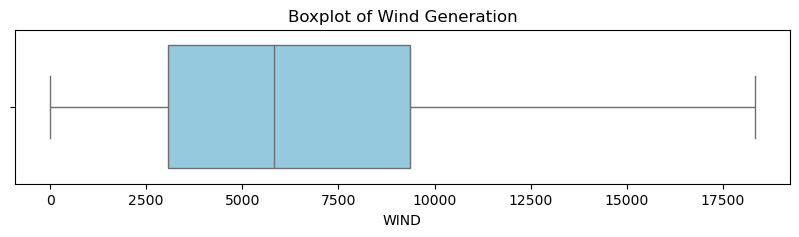

In [19]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=f_sample,
    color="skyblue"
)

plt.title("Boxplot of Wind Generation")

plt.show()

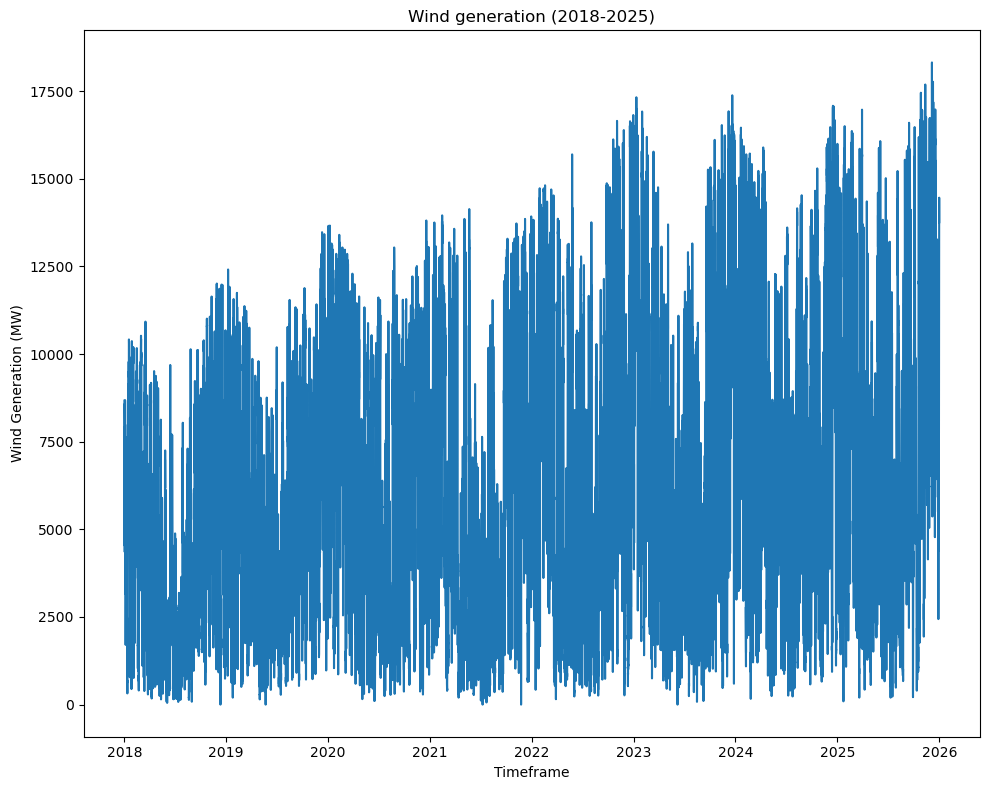

In [20]:
plt.figure(figsize=(10,8))

sns.lineplot(
    vws_dataset,
    x="timestamp",
    y="WIND"    
)

plt.title("Wind generation (2018-2025)")
plt.xlabel("Timeframe")
plt.ylabel("Wind Generation (MW)")
plt.tight_layout()

plt.show()

<Axes: xlabel='WIND', ylabel='Count'>

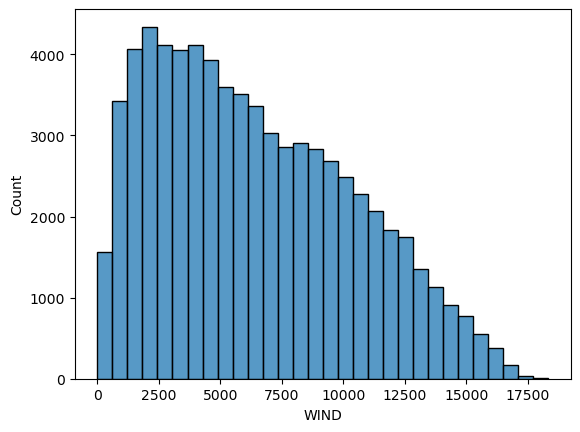

In [21]:
sns.histplot(vws_dataset["WIND"], bins=30)

<Axes: xlabel='hour', ylabel='WIND'>

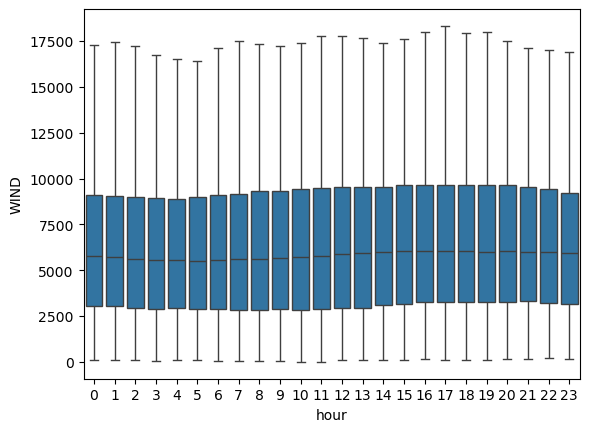

In [22]:
vws_dataset["hour"] = vws_dataset["timestamp"].dt.hour
sns.boxplot(vws_dataset, x = "hour", y= "WIND")

<Axes: xlabel='month', ylabel='WIND'>

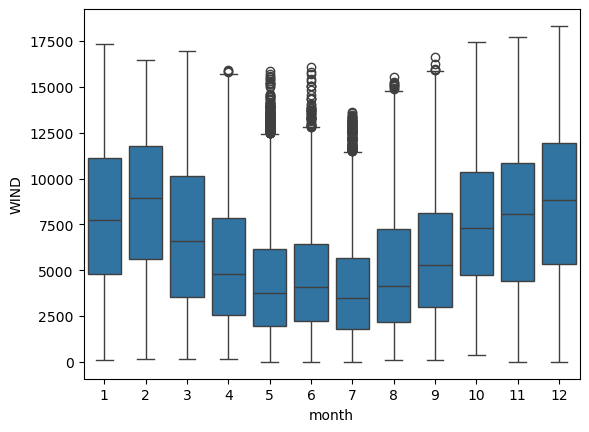

In [23]:
vws_dataset["month"] = vws_dataset["timestamp"].dt.month

sns.boxplot(vws_dataset, x="month", y="WIND")

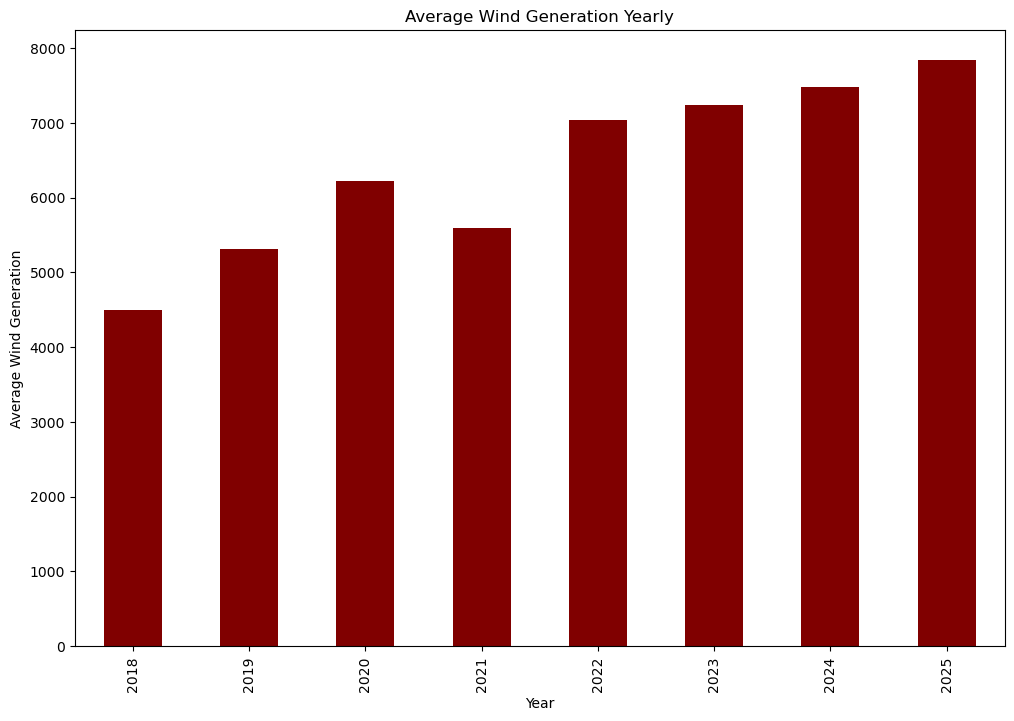

In [24]:
monthly_avg = (
    vws_dataset
    .groupby(vws_dataset["timestamp"].dt.year)["WIND"]
    .mean()
)

plt.figure(figsize=(12,8))
monthly_avg.plot(kind="bar", color="maroon")
plt.title("Average Wind Generation Yearly")
plt.xlabel("Year")
plt.ylabel("Average Wind Generation")
plt.show()

<Axes: ylabel='WIND'>

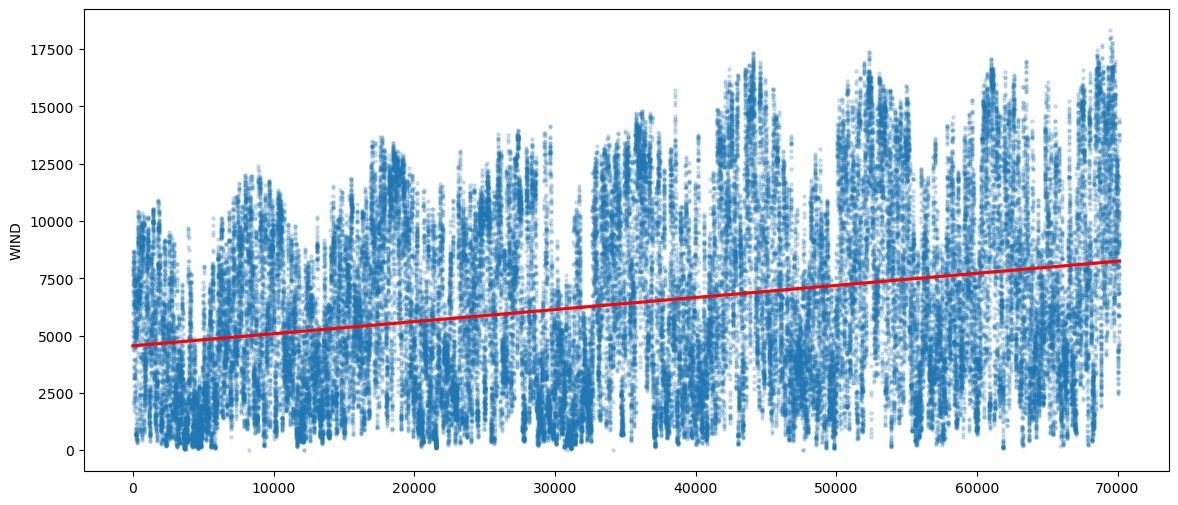

In [25]:
plt.figure(figsize=(14,6))

sns.regplot(
    vws_dataset,
    x=vws_dataset.index,
    y="WIND",
    scatter_kws={'s':5, 'alpha':0.2},
    line_kws={'color': 'red'}
)

Weather Variables

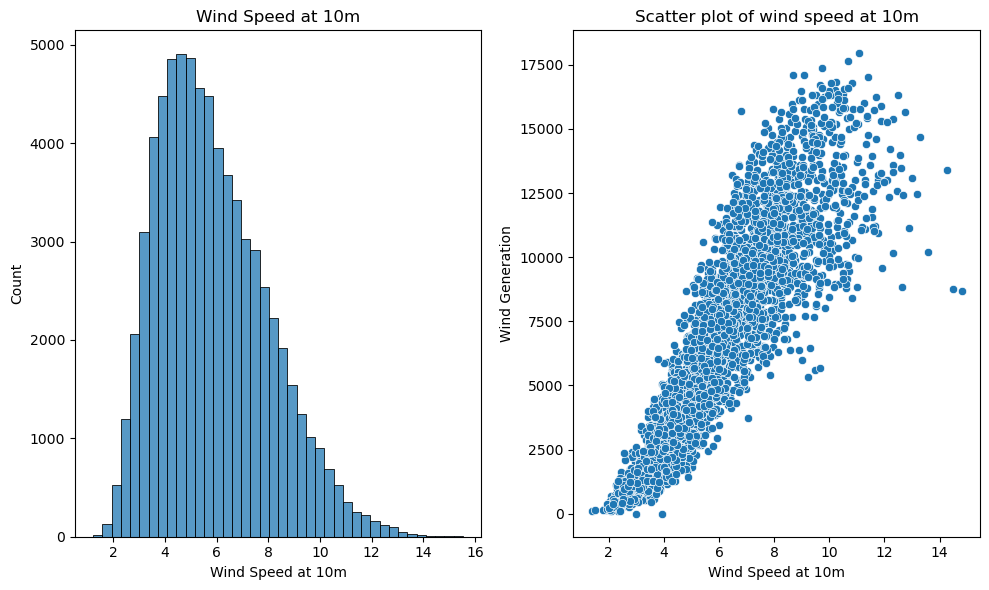

In [26]:
#histogram

plt.figure(figsize=(10,6))


plt.subplot(1,2,1)
sns.histplot(
    vws_dataset["ws10"],
    bins=40
)
plt.xlabel("Wind Speed at 10m")
plt.title("Wind Speed at 10m")

plt.subplot(1,2,2)
sns.scatterplot(
    vws_dataset.sample(4000, random_state=42),
    x="ws10",
    y="WIND"
)
plt.xlabel("Wind Speed at 10m")
plt.ylabel("Wind Generation")
plt.title("Scatter plot of wind speed at 10m")

plt.tight_layout()
plt.show()

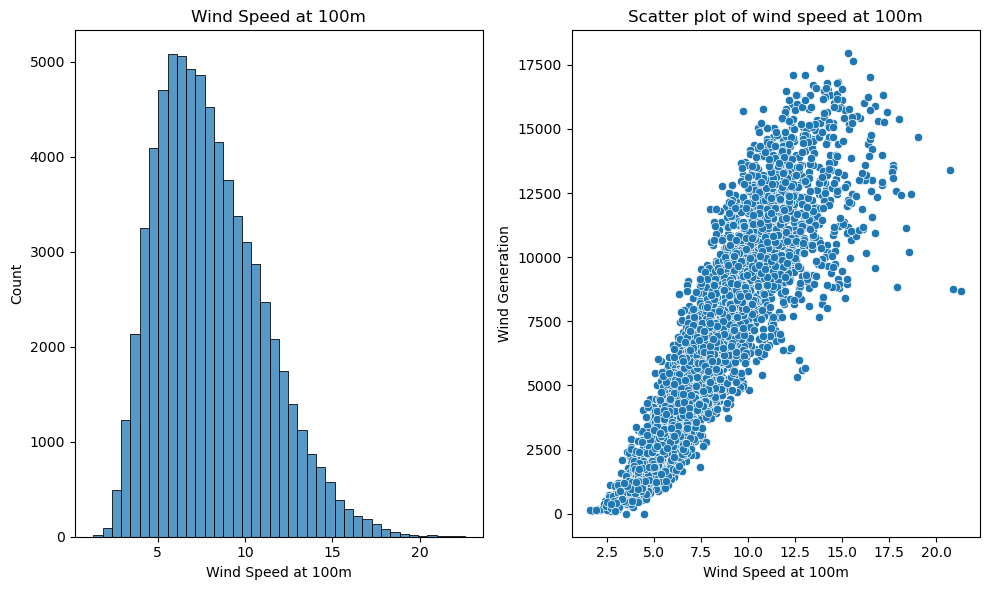

In [27]:
#histogram

plt.figure(figsize=(10,6))


plt.subplot(1,2,1)
sns.histplot(
    vws_dataset["ws100"],
    bins=40
)
plt.xlabel("Wind Speed at 100m")
plt.title("Wind Speed at 100m")

plt.subplot(1,2,2)
sns.scatterplot(
    vws_dataset.sample(4000, random_state=42),
    x="ws100",
    y="WIND"
)
plt.xlabel("Wind Speed at 100m")
plt.ylabel("Wind Generation")
plt.title("Scatter plot of wind speed at 100m")

plt.tight_layout()
plt.show()

In [28]:
vws_dataset["year"] = vws_dataset["timestamp"].dt.year

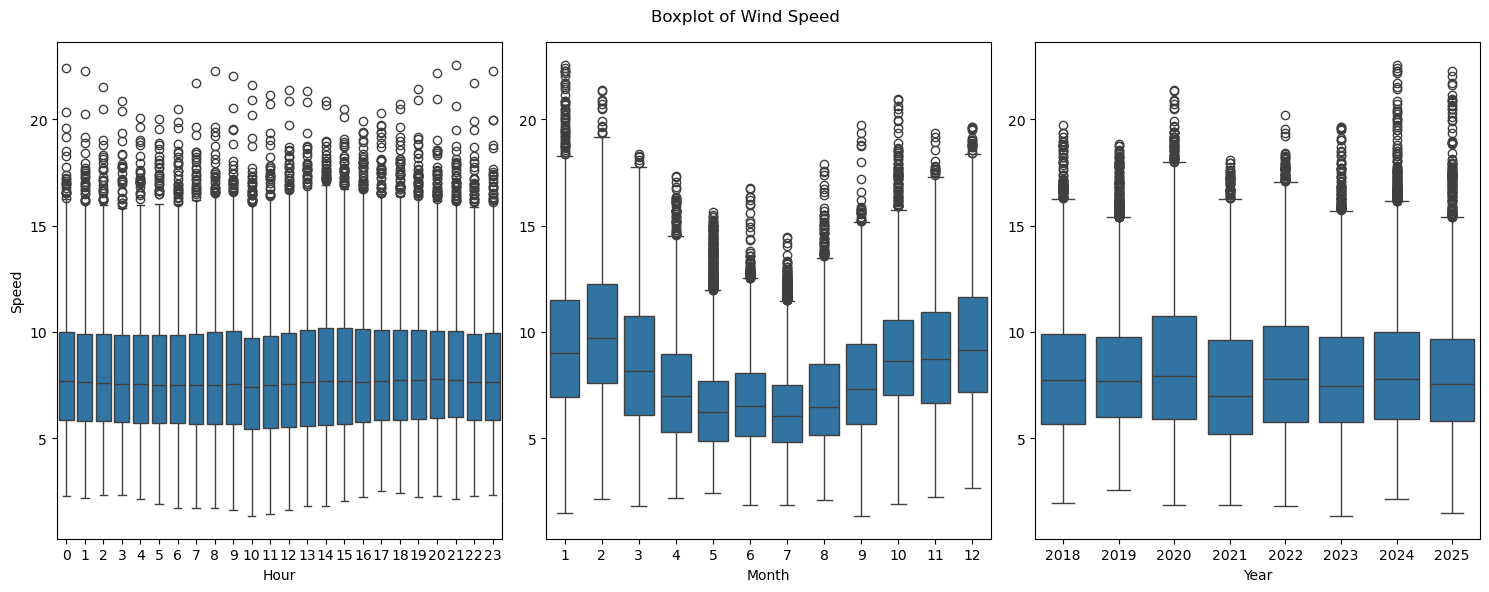

In [29]:
plt.figure(figsize=(15,6))

plt.subplot(1,3,1)
sns.boxplot(
    vws_dataset,
    x="hour",
    y="ws100"
)
plt.xlabel("Hour")
plt.ylabel("Speed")

plt.subplot(1,3,2)
sns.boxplot(
    vws_dataset,
    x="month",
    y="ws100"
)
plt.xlabel("Month")
plt.ylabel(None)

plt.subplot(1,3,3)
sns.boxplot(
    vws_dataset,
    x="year",
    y="ws100"
)
plt.xlabel("Year")
plt.ylabel(None)

plt.suptitle("Boxplot of Wind Speed")
plt.tight_layout()

plt.show()

In [8]:
#!pip install windrose

  Using cached windrose-1.10.0-py3-none-any.whl.metadata (5.3 kB)
Using cached windrose-1.10.0-py3-none-any.whl (20 kB)


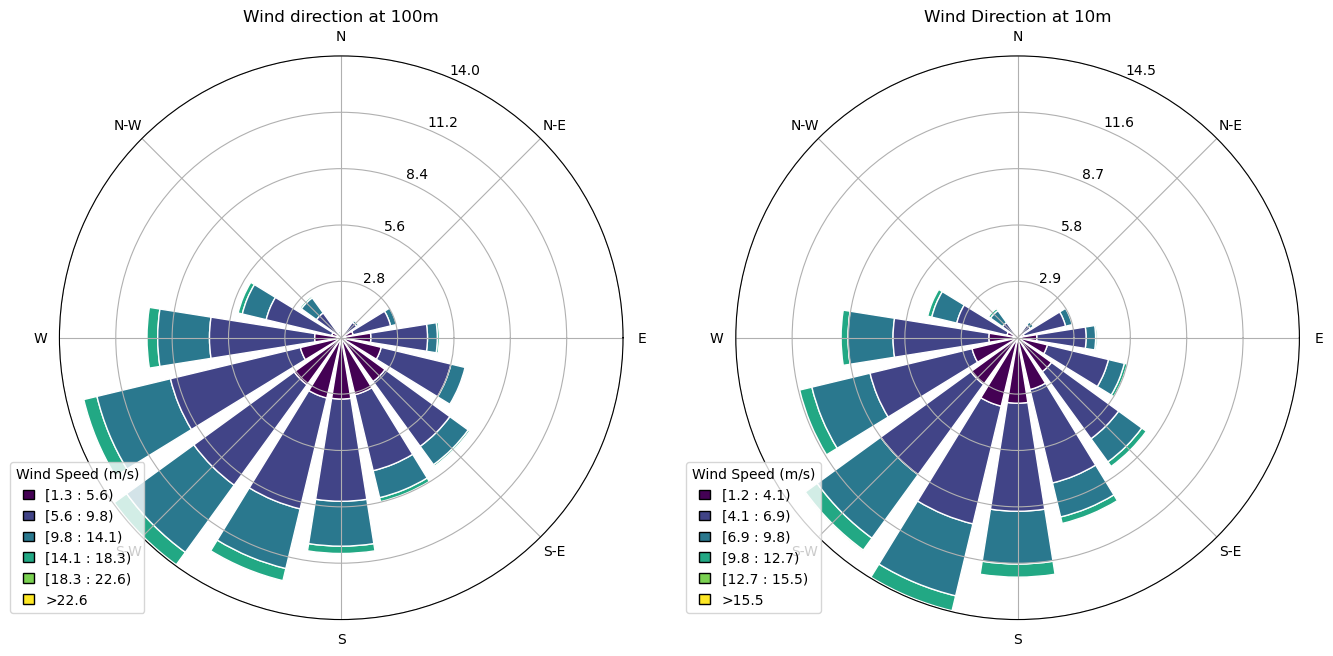

In [30]:
from windrose import WindroseAxes

fig, ax= plt.subplots(
    1,2,
    figsize=(16,8),
    subplot_kw={"projection":"windrose"},
    squeeze=True
)

ax[0].bar(
    vws_dataset["wd100"],
    vws_dataset["ws100"],
    normed=True,
    opening=0.8,
    edgecolor="white"
)

ax[0].set_title("Wind direction at 100m", pad=25)
ax[0].legend(
    title="Wind Speed (m/s)",
    loc= "lower left",
    bbox_to_anchor = (-0.10, 0.0),
    handlelength = 0.8
)

ax[1].bar(
    vws_dataset["wd10"],
    vws_dataset["ws10"],
    normed=True,
    opening=0.8,
    edgecolor="white"
)

ax[1].set_title("Wind Direction at 10m", pad=25)
ax[1].legend(
    title="Wind Speed (m/s)",
    loc= "lower left",
    bbox_to_anchor = (-0.10, 0.0),
    handlelength = 0.8
)


plt.show()

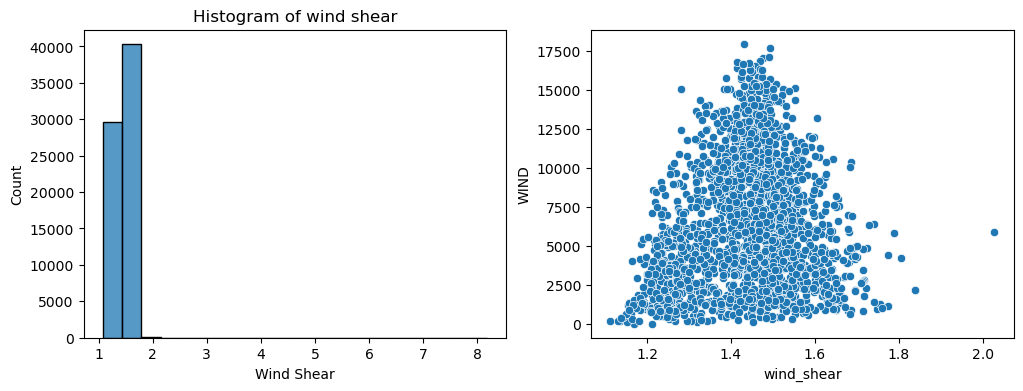

In [31]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(
    vws_dataset["wind_shear"],
    bins=20
)

plt.xlabel("Wind Shear")
plt.ylabel("Count")
plt.title("Histogram of wind shear")

plt.subplot(1,2,2)
sns.scatterplot(
    vws_dataset.sample(2000, random_state=42),
    x="wind_shear",
    y="WIND"
)

plt.show()

In [32]:
sort = vws_dataset["wind_shear"].sort_values()

In [33]:
sort.tail(10)

31994    2.265958
58508    2.396887
21094    2.402666
24007    2.659900
47880    2.677499
12956    2.931367
22908    3.077105
63234    4.050456
66165    5.097826
24055    8.180838
Name: wind_shear, dtype: float64

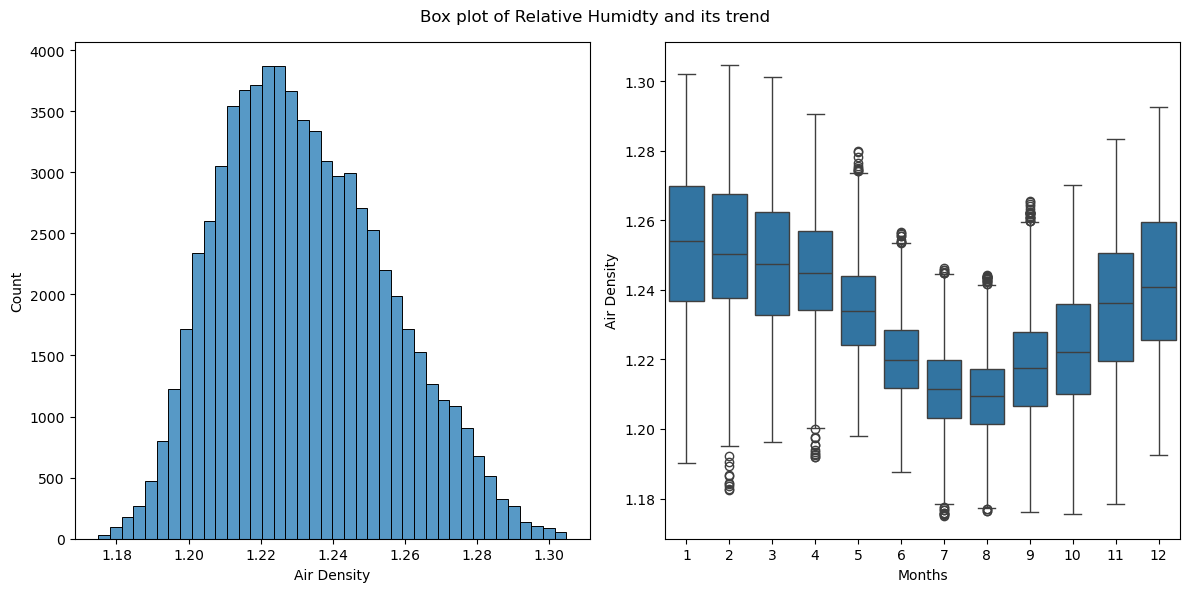

In [34]:
#air_density
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.histplot(
    vws_dataset["air_density"],
    bins=40
)
plt.xlabel("Air Density")

plt.subplot(1,2,2)
sns.boxplot(
    vws_dataset,
    x="month",
    y="air_density"
)
plt.ylabel("Air Density")
plt.xlabel("Months")

plt.suptitle("Box plot of Relative Humidty and its trend")
plt.tight_layout()
plt.show()

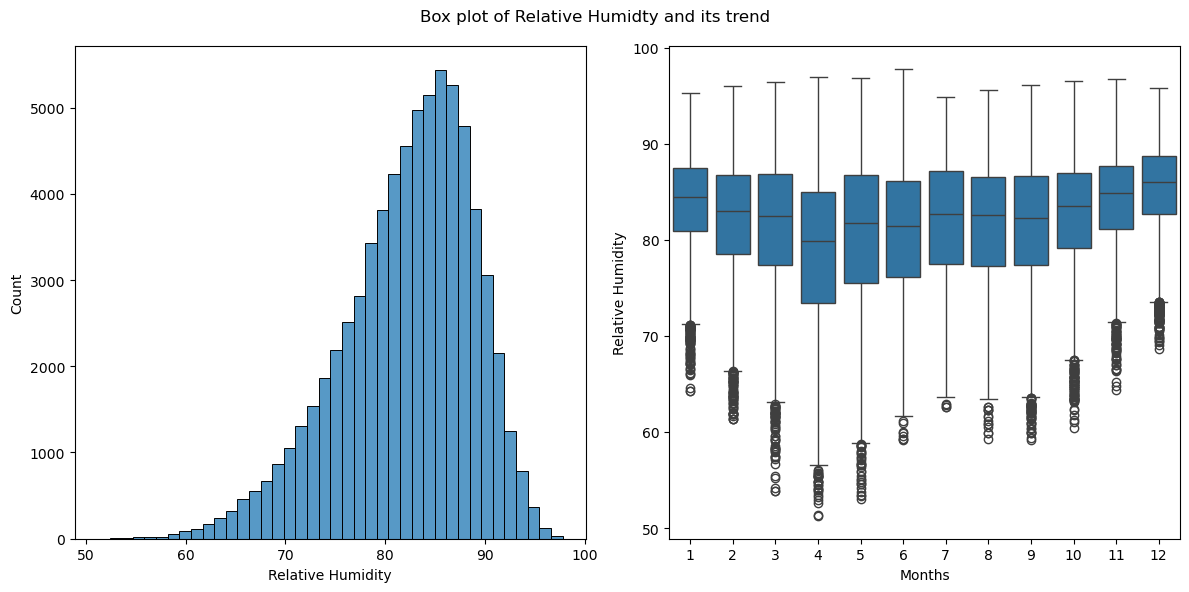

In [35]:
#relative_humidity
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.histplot(
    vws_dataset["relative_humidity"],
    bins=40
)
plt.xlabel("Relative Humidity")

plt.subplot(1,2,2)
sns.boxplot(
    vws_dataset,
    x="month",
    y="relative_humidity"
)
plt.ylabel("Relative Humidity")
plt.xlabel("Months")

plt.suptitle("Box plot of Relative Humidty and its trend")
plt.tight_layout()
plt.show()

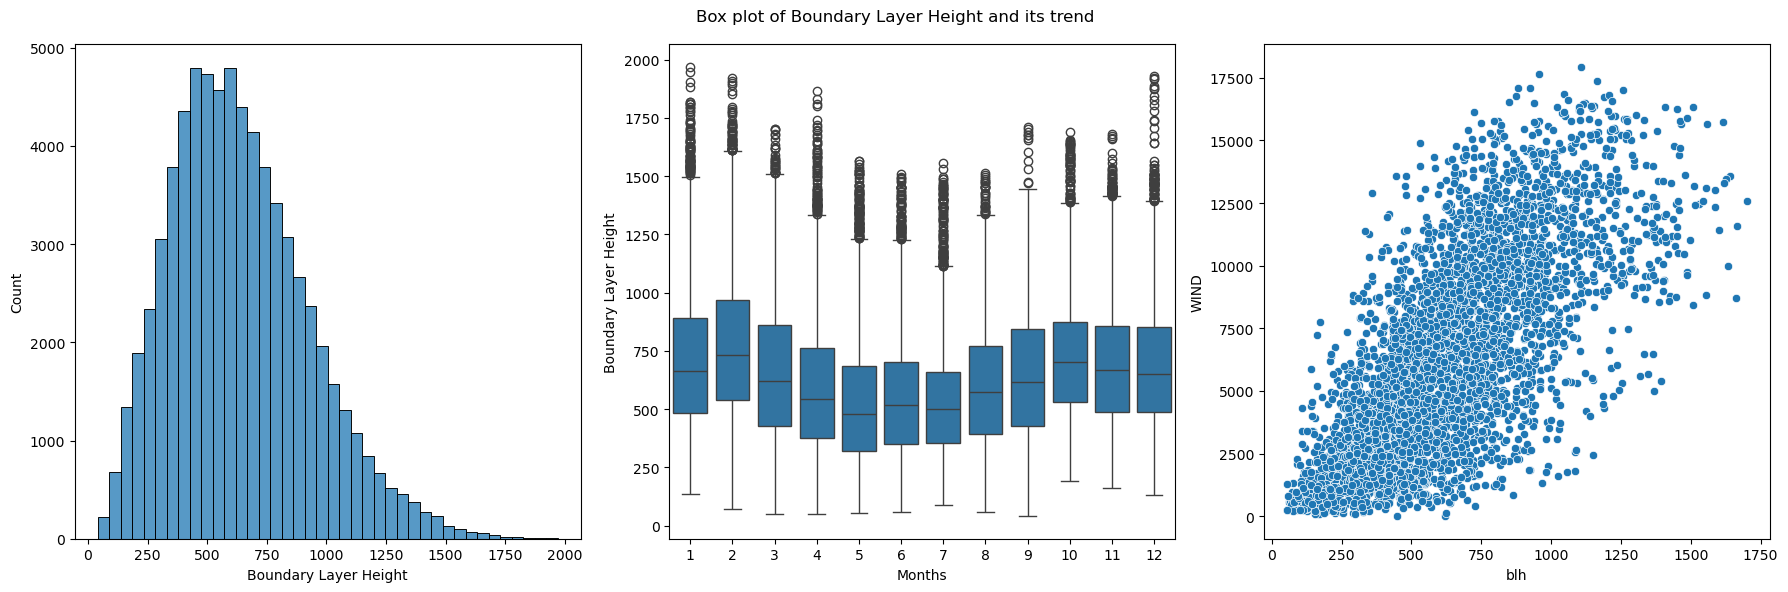

In [36]:
#blh

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
sns.histplot(
    vws_dataset["blh"],
    bins=40
)
plt.xlabel("Boundary Layer Height")

plt.subplot(1,3,2)
sns.boxplot(
    vws_dataset,
    x="month",
    y="blh"
)
plt.ylabel("Boundary Layer Height")
plt.xlabel("Months")

plt.subplot(1,3,3)
sns.scatterplot(
    vws_dataset.sample(4000, random_state=42),
    x="blh",
    y="WIND"
)

plt.suptitle("Box plot of Boundary Layer Height and its trend")
plt.tight_layout()
plt.show()

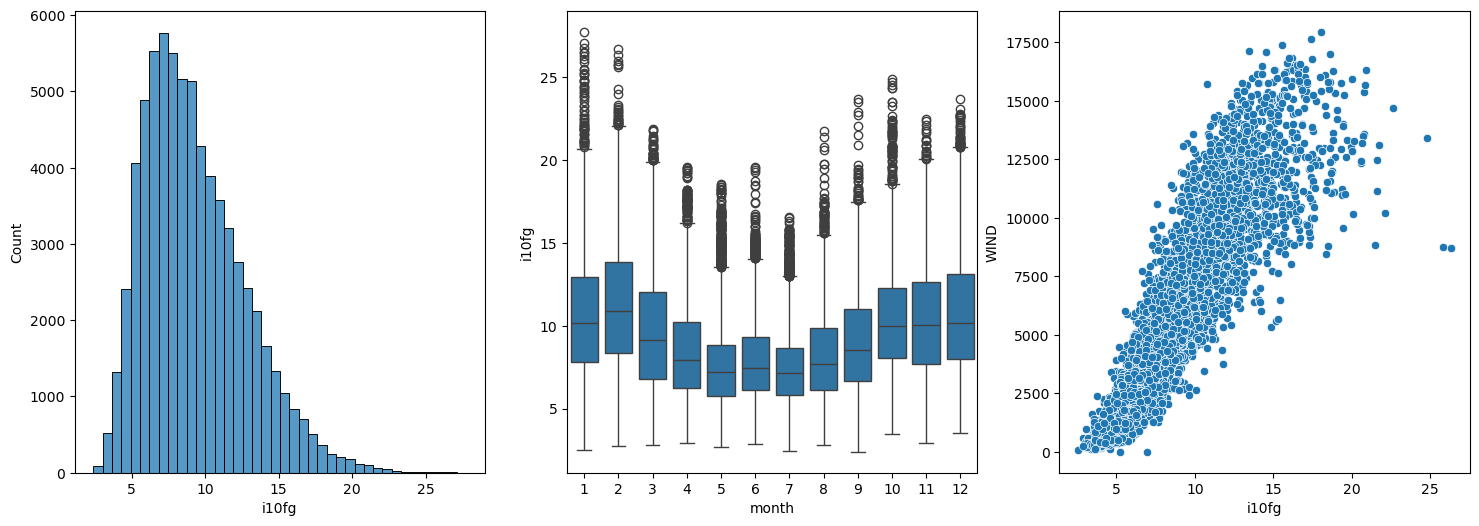

In [37]:
#ins10

#blh

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
sns.histplot(
    vws_dataset["i10fg"],
    bins=40
)

plt.subplot(1,3,2)
sns.boxplot(
    vws_dataset,
    x="month",
    y="i10fg"
)

plt.subplot(1,3,3)
sns.scatterplot(
    vws_dataset.sample(4000, random_state=42),
    x="i10fg",
    y="WIND"
)

plt.show()

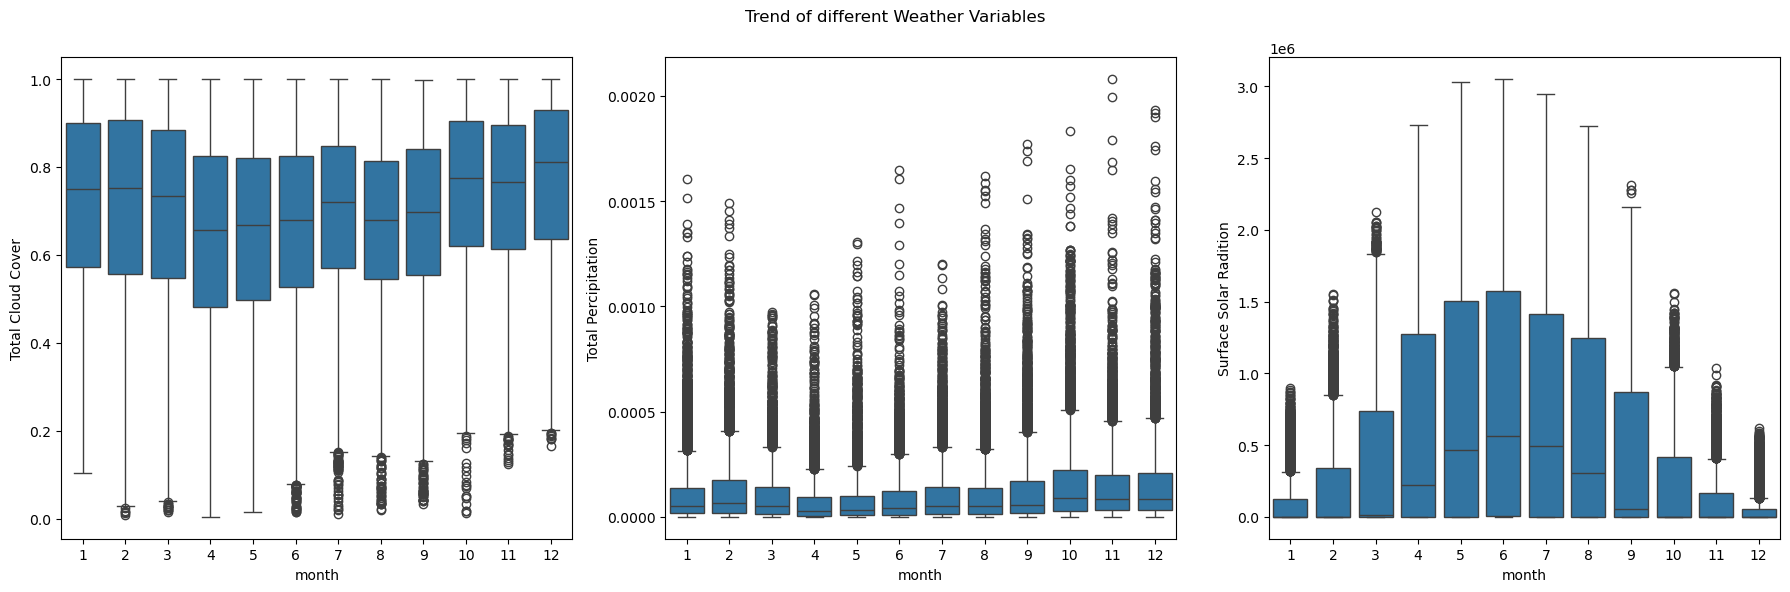

In [75]:
#blh

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
sns.boxplot(
    vws_dataset,
    x="month",
    y="tcc"
)
plt.ylabel("Total Cloud Cover")

plt.subplot(1,3,2)
sns.boxplot(
    vws_dataset,
    x="month",
    y="tp"
)
plt.ylabel("Total Percipitation")

plt.subplot(1,3,3)
sns.boxplot(
    vws_dataset,
    x="month",
    y="ssrd"
)
plt.ylabel("Surface Solar Radition")

plt.suptitle("Trend of different Weather Variables")
plt.tight_layout()
plt.show()

In [47]:
vws_data = vws_dataset

In [48]:
# removing timeline variables for correlation matrix
del vws_data["timestamp"]

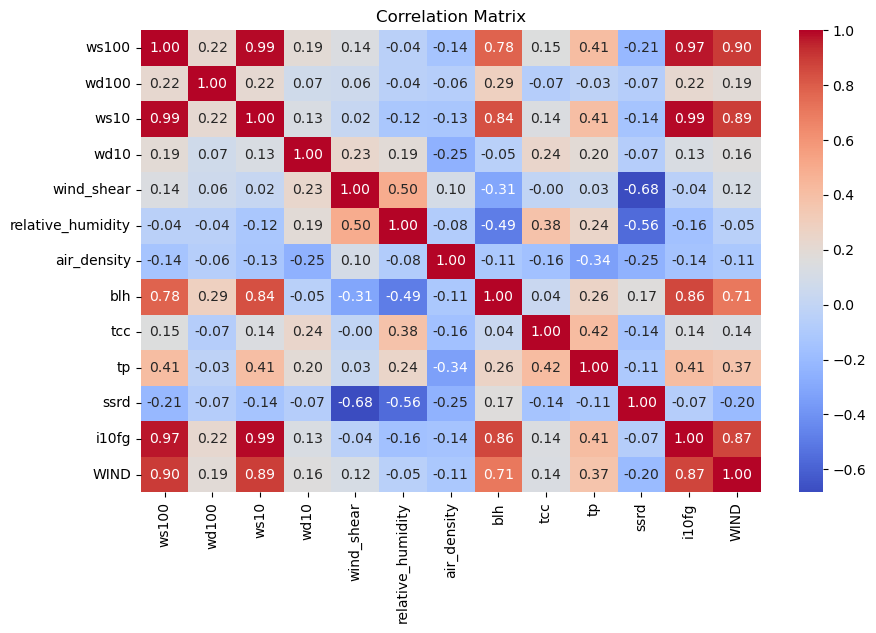

In [49]:
#correlation matrix

corr_matrix = vws_data.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True, #show values
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


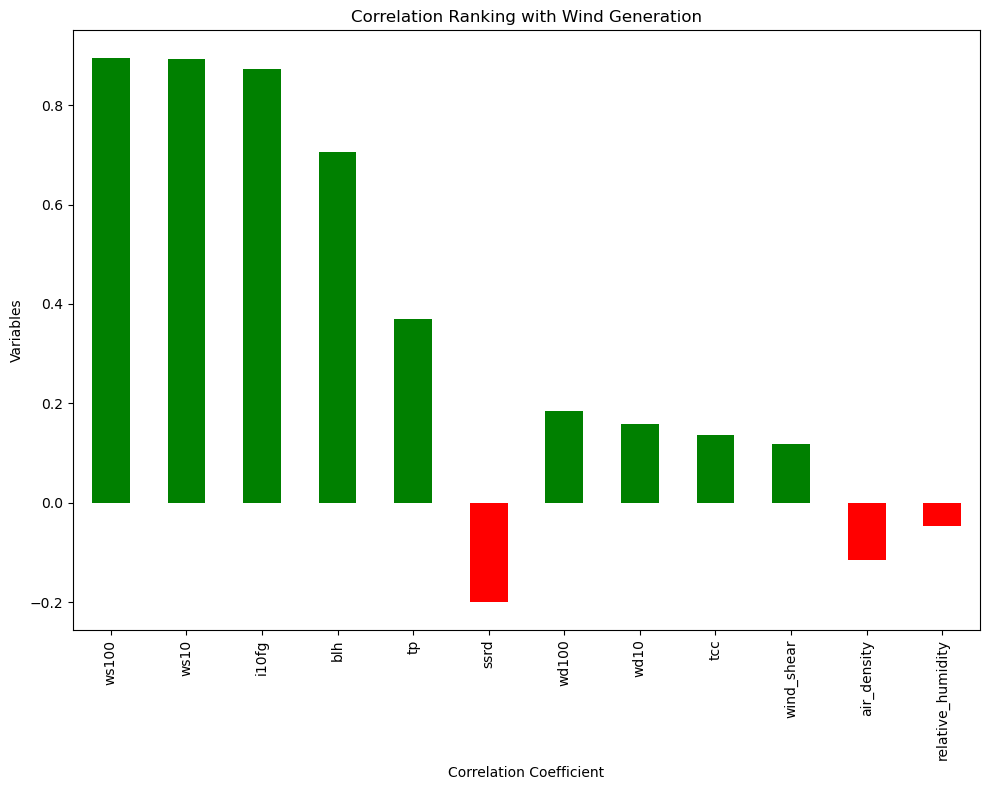

In [50]:
#correlation with target variable

corr_ranking = (
    corr_matrix["WIND"]
    .drop("WIND")
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10,8))

corr_ranking.plot(
    kind="bar",
    color=["green" if x>0 else "red" for x in corr_ranking]
)

plt.xlabel("Correlation Coefficient")
plt.ylabel("Variables")
plt.title("Correlation Ranking with Wind Generation")

plt.tight_layout()
plt.show()

In [63]:
multi_corr = corr_matrix.copy()

In [69]:
multi_corr.columns

Index(['ws100', 'wd100', 'ws10', 'wd10', 'wind_shear', 'relative_humidity',
       'air_density', 'blh', 'tcc', 'tp', 'ssrd', 'i10fg'],
      dtype='object')

In [65]:
del multi_corr["WIND"]

In [66]:
multi_corr.head()

,ws100,wd100,ws10,wd10,wind_shear,relative_humidity,air_density,blh,tcc,tp,ssrd,i10fg
ws100,1.000000,0.217618,0.987826,0.191303,0.141795,-0.041760,-0.143604,0.777868,0.152229,0.411229,-0.214755,0.973203
wd100,0.217618,1.000000,0.217033,0.074763,0.059537,-0.044428,-0.060244,0.285341,-0.071331,-0.025495,-0.065619,0.222028
ws10,0.987826,0.217033,1.000000,0.125955,0.024849,-0.122651,-0.130269,0.838804,0.139016,0.406847,-0.143431,0.990953
wd10,0.191303,0.074763,0.125955,1.000000,0.231799,0.189447,-0.253152,-0.049894,0.243227,0.196383,-0.066813,0.130792
wind_shear,0.141795,0.059537,0.024849,0.231799,1.000000,0.496157,0.104193,-0.309040,-0.001981,0.028006,-0.683773,-0.042669


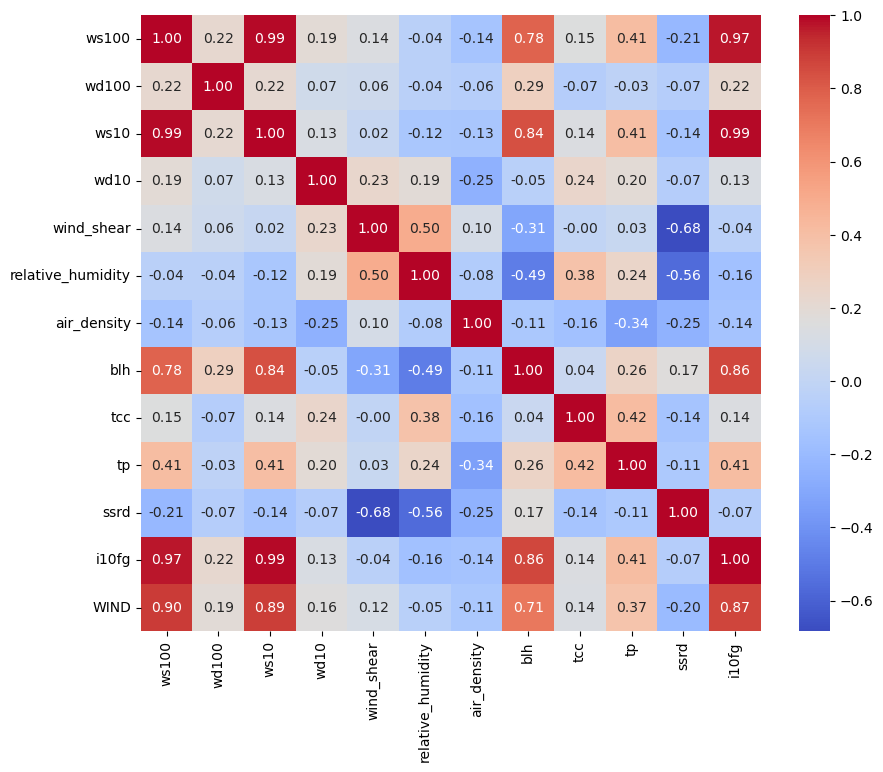

In [68]:
plt.figure(figsize=(10,8))

sns.heatmap(
    multi_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [44]:
%reset